# 04 — Exploratory Data Analysis

**Input:** `data/processed/groundwater_clean_2018_2020.csv`

Understand the cleaned data before modelling:

1. distributions of key chemistry parameters
2. per-district **fluoride** and **nitrate** hotspots (the two health-critical BIS parameters)
3. year-over-year trends
4. drinking-risk composition

Read-only analysis — produces no new data files.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "groundwater_clean_2018_2020.csv")
print("Shape:", df.shape, "| Years:", sorted(df["year"].unique()), "| Districts:", df["district"].nunique())
df.describe().T

Shape: (1106, 27) | Years: [np.int64(2018), np.int64(2019), np.int64(2020)] | Districts: 33


,count,mean,std,min,25%,50%,75%,max
year,1106.0,2018.994575,0.819429,2018.000000,2018.000000,2019.000000,2020.000000,2020.000000
sno,1106.0,189.420434,110.031182,1.000000,94.000000,188.500000,285.000000,379.000000
lat,1106.0,17.708504,0.852864,15.896441,17.136028,17.639128,18.359652,19.730555
lon,1106.0,78.790897,0.818382,77.444000,78.184623,78.579444,79.351937,80.920000
gwl,1106.0,8.578743,7.492729,0.170000,3.070000,5.935000,12.295000,43.170000
ph,1105.0,7.849457,0.457150,6.110000,7.500000,7.860000,8.180000,10.440000
ec,1106.0,1362.238698,861.061139,205.000000,782.000000,1179.500000,1673.500000,9499.000000
tds,1106.0,871.832767,551.079129,131.200000,500.480000,754.880000,1071.040000,6079.360000
co3,946.0,6.822446,17.217132,0.000000,0.000000,0.000000,0.000000,100.000000
hco3,1106.0,300.751525,135.121572,30.000000,200.000000,290.000000,380.000000,1070.000000


## 1. Distributions of key parameters

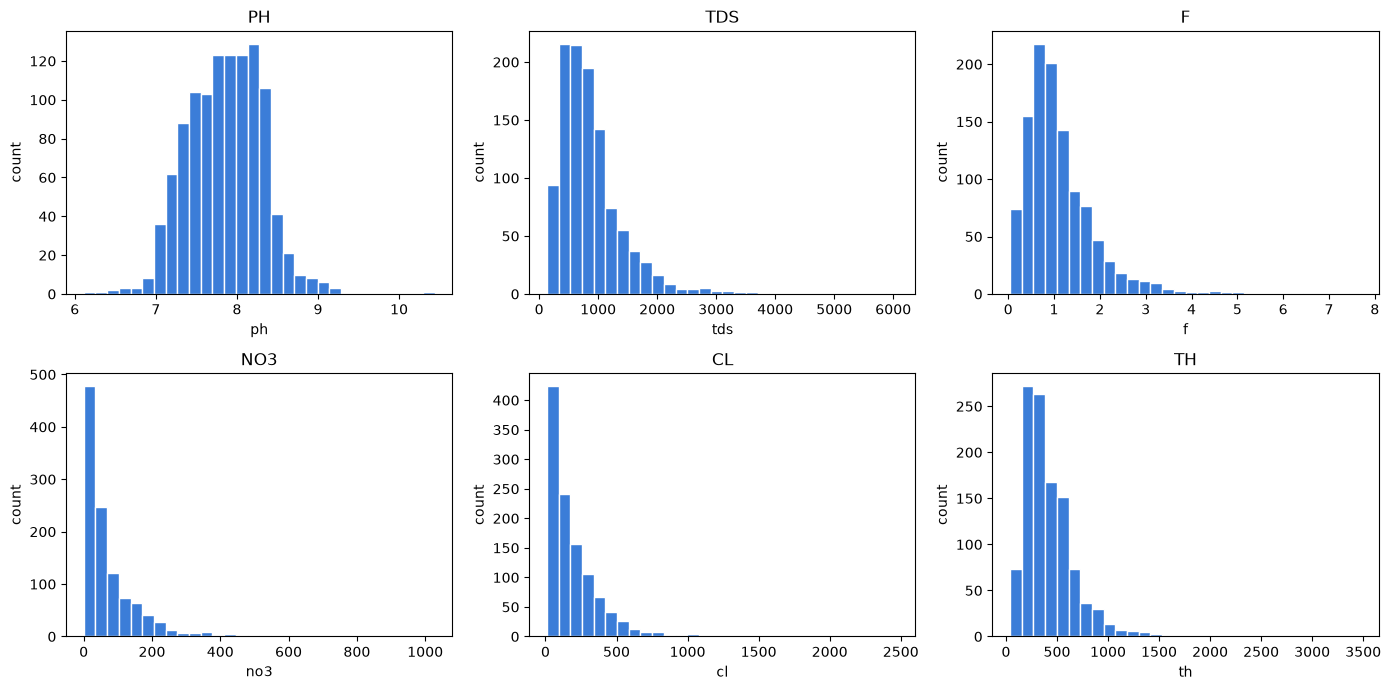

In [2]:
params = ["ph","tds","f","no3","cl","th"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, p in zip(axes.ravel(), params):
    ax.hist(df[p].dropna(), bins=30, color="#3b7dd8", edgecolor="white")
    ax.set_title(p.upper()); ax.set_xlabel(p); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 2. Fluoride & nitrate hotspots by district

BIS limits: fluoride 1.0 mg/L, nitrate 45 mg/L. Top districts by mean concentration.

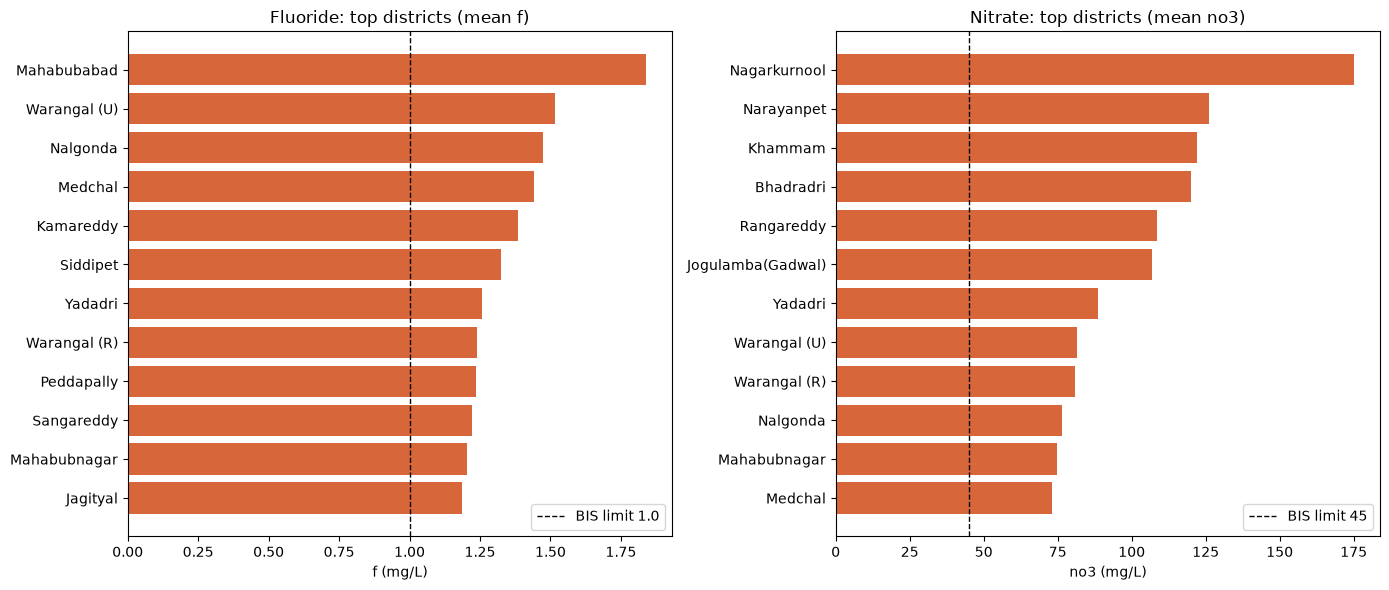

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (col, limit, name) in zip(axes, [("f",1.0,"Fluoride"),("no3",45,"Nitrate")]):
    top = df.groupby("district")[col].mean().sort_values(ascending=False).head(12)
    ax.barh(top.index[::-1], top.values[::-1], color="#d8663b")
    ax.axvline(limit, color="black", ls="--", lw=1, label=f"BIS limit {limit}")
    ax.set_title(f"{name}: top districts (mean {col})"); ax.set_xlabel(f"{col} (mg/L)"); ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# % of samples exceeding the health limit, per district (fluoride)
f_exc = (df.assign(exc=df["f"] > 1.0)
           .groupby("district")["exc"].mean().mul(100)
           .sort_values(ascending=False).head(10))
print("Top districts by % fluoride exceedance:")
print(f_exc.round(1).to_string())

Top districts by % fluoride exceedance:
district
Sangareddy      69.7
Suryapet        66.7
Mahabubabad     66.7
Medchal         61.9
Kamareddy       61.3
Mahabubnagar    60.0
Siddipet        59.1
Yadadri         58.1
Nalgonda        55.3
Warangal (U)    55.0


## 3. Year-over-year trends

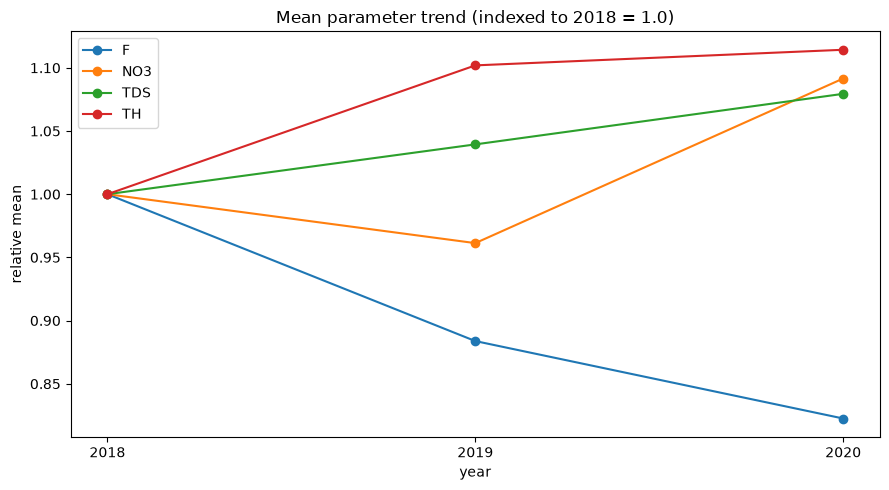

,f,no3,tds,th
year,,,,
2018,1.24,73.77,838.79,391.20
2019,1.09,70.91,871.85,431.08
2020,1.02,80.52,905.41,435.91


In [5]:
yearly = df.groupby("year")[["f","no3","tds","th"]].mean()
fig, ax = plt.subplots(figsize=(9,5))
for c in ["f","no3","tds","th"]:
    ax.plot(yearly.index, yearly[c]/yearly[c].iloc[0], marker="o", label=c.upper())
ax.set_title("Mean parameter trend (indexed to 2018 = 1.0)")
ax.set_xlabel("year"); ax.set_ylabel("relative mean"); ax.set_xticks(yearly.index); ax.legend()
plt.tight_layout(); plt.show()
yearly.round(2)

## 4. Drinking-risk composition

Recompute the BIS label here so EDA is self-contained.

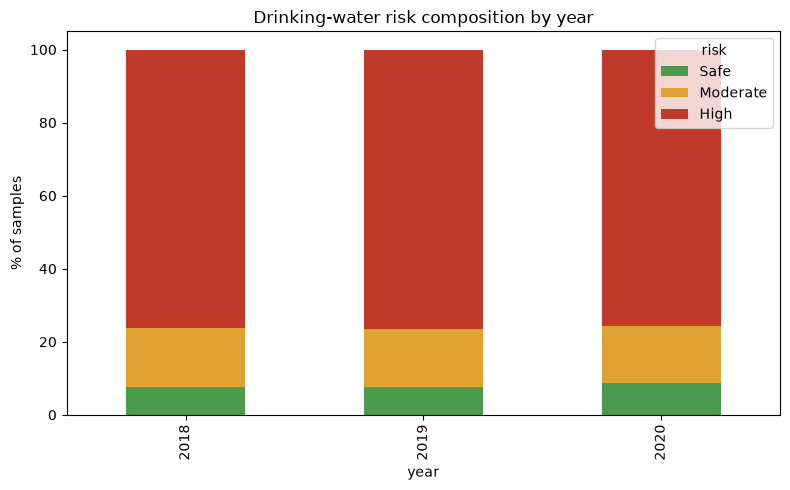

_risk,Safe,Moderate,High
year,,,
2018,7.8,16.0,76.2
2019,7.7,15.9,76.4
2020,8.7,15.8,75.5


In [6]:
BIS = {"ph_low":6.5,"ph_high":8.5,"tds":500,"th":200,"cl":250,"f":1.0,"no3":45,"so4":200,"ca":75,"mg":30}
def exc(row):
    n = 0
    if pd.notna(row["ph"]) and not (BIS["ph_low"] <= row["ph"] <= BIS["ph_high"]): n += 1
    for k in ["tds","th","cl","f","no3","so4","ca","mg"]:
        if pd.notna(row[k]) and row[k] > BIS[k]: n += 1
    return n
df["_risk"] = df.apply(exc, axis=1).apply(lambda n: "Safe" if n==0 else ("Moderate" if n<=2 else "High"))

comp = (df.groupby("year")["_risk"].value_counts(normalize=True).mul(100)
          .unstack().reindex(columns=["Safe","Moderate","High"]))
comp.plot(kind="bar", stacked=True, figsize=(8,5),
          color={"Safe":"#4c9a4c","Moderate":"#e0a233","High":"#c0392b"})
plt.ylabel("% of samples"); plt.title("Drinking-water risk composition by year")
plt.legend(title="risk"); plt.tight_layout(); plt.show()
comp.round(1)